In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar variáveis do .env
load_dotenv()

user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('DB_NAME')

In [ ]:
# Criação da engine de conexão
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}')

# Consulta com pandas
df = pd.read_sql(f'SELECT * FROM tabela_RFV', con=engine)


recencia = df['recencia_dias']
frequencia = df['qtd_pedidos']
valor = df['valor_monetario']

In [3]:
def plot_boxplot(df, title='', ax=None, figsize=(9, 4)):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(x=df, ax=ax)
    ax.set_title(title)

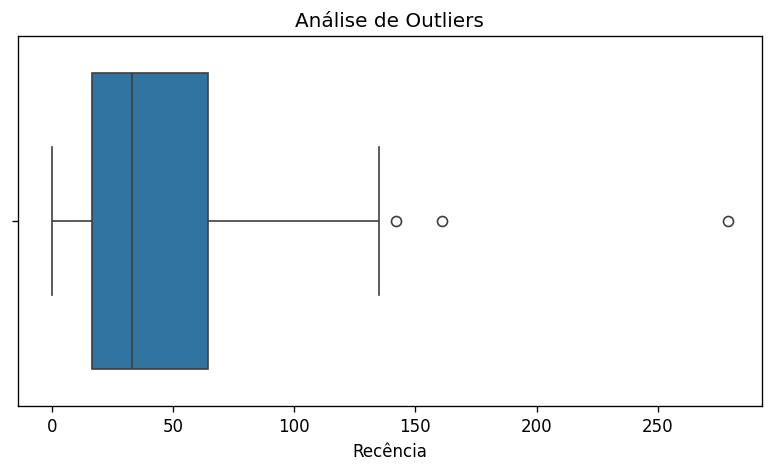

In [11]:
fig, ax = plt.subplots(1, 1, dpi=120, figsize=(8, 4))
plot_boxplot(recencia, title='Análise de Outliers', ax=ax)
ax.set_xlabel("Recência")
plt.show()


In [5]:
recencia.describe()

count     67.000000
mean      48.641791
std       48.694378
min        0.000000
25%       16.500000
50%       33.000000
75%       64.500000
max      279.000000
Name: recencia_dias, dtype: float64

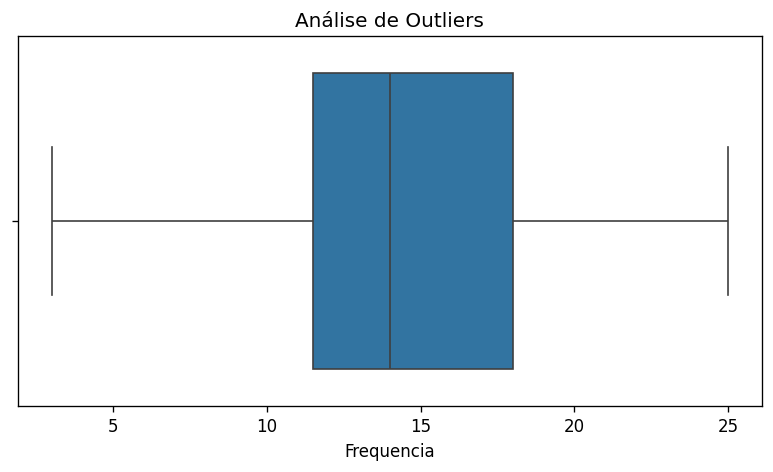

In [13]:
fig, ax = plt.subplots(1, 1, dpi=120, figsize=(8, 4))
plot_boxplot(frequencia, title='Análise de Outliers', ax=ax)
ax.set_xlabel("Frequencia")
plt.show()


In [7]:
frequencia.describe()

count    67.000000
mean     14.925373
std       4.442609
min       3.000000
25%      11.500000
50%      14.000000
75%      18.000000
max      25.000000
Name: qtd_pedidos, dtype: float64

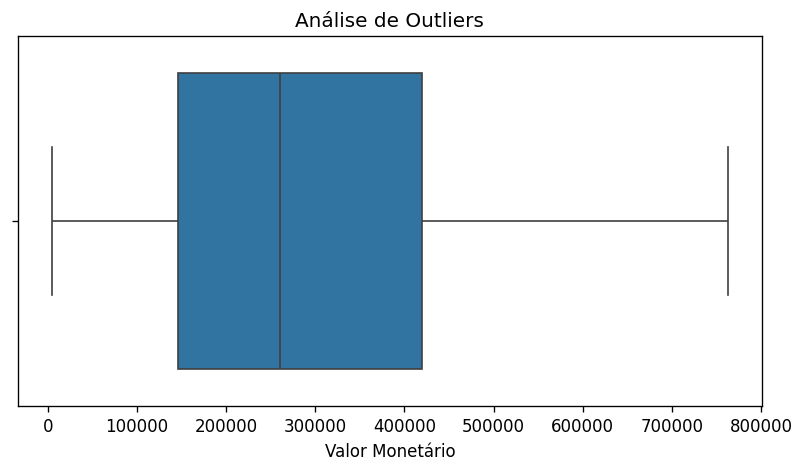

In [14]:
fig, ax = plt.subplots(1, 1, dpi=120, figsize=(8, 4))
plot_boxplot(valor, title='Análise de Outliers', ax=ax)
ax.set_xlabel("Valor Monetário")
plt.show()

In [9]:
valor.describe()

count        67.000000
mean     288175.992537
std      170000.623928
min        4255.000000
25%      145477.500000
50%      260061.000000
75%      420132.500000
max      762982.000000
Name: valor_monetario, dtype: float64